<div style="border:2px solid #b0c4b1; padding:20px; border-radius:6px;">
  <h3 style="color:#333; margin:0; font-size:35px;">Residual Iteration Decomposition (RIDE) method </h3>
</div>

The RIDE method uses an iterative algorithm that produces estimates of each deconvoluted subcomponent within each iteration until the estimates converge. 
This results in separate subcomponents of the ERP signals that are time locked to either stimulus onset (termed the stimulus-locked subcomponent) or the response (termed the response-locked subcomponent). 

Is niet per se een feature extraction methode, maar eerder om de timing ruis te filteren en daarna beter features te kunnen extracten.

Inputs:
- preprocessed EEG data -> data matrix with the shape (n_trials, n_channels, n_timepoints) that contains the single trial ERP amplitudes in microvolts
- Reaction times

In [ ]:
import pandas as pd 
import mne
from mne import read_epochs
from ride import RideCfg, correct_trials, ride_call
from pathlib import Path
import numpy as np

# ---------------------------
# Load data
# ---------------------------
output_dir = Path(r"C:\Master Thesis BDS\derivatives")
sub = 'sub-LTP063'
ses = 'ses-0'

epo_file = output_dir / f'{sub}_{ses}_epo.fif'
epochs = mne.read_epochs(epo_file, verbose=False)

epochs_ride = epochs.copy().crop(tmin=0.0, tmax=2.2)
epochs_ride.resample(200)

# RT in samples
rt_samples = np.round(
    epochs_ride.metadata['RT'].to_numpy()
    * epochs_ride.info['sfreq']
).astype(int)

rt_samples = rt_samples.ravel()


# --------------------------------------------------
# EEG data
# MNE format:
# (epochs, channels, times)
# --------------------------------------------------

data_test = epochs_ride.get_data()

print("Original:")
print(data_test.shape)


# RIDE verwacht:
# (times, channels, epochs)

data_test = np.transpose(data_test, (2, 1, 0))

print("RIDE:")
print(data_test.shape)


# --------------------------------------------------
# Sanity check
# --------------------------------------------------

n_times, n_channels, n_trials = data_test.shape

print(f"Trials:      {n_trials}")
print(f"RT samples:  {len(rt_samples)}")
print(f"Channels:    {n_channels}")
print(f"Times:       {n_times}")

assert n_trials == len(rt_samples)


# --------------------------------------------------
# Latencies
# BELANGRIJK:
# expliciete vector voor stimulus component
# --------------------------------------------------

s_latency = np.zeros(
    len(rt_samples),
    dtype=int
)


# --------------------------------------------------
# RIDE config
# --------------------------------------------------

cfg = RideCfg(
    comp_name=['s', 'r'],
    comp_twd=[
        [0, 600],
        [-400, 200]
    ],
    comp_latency=[
        s_latency,
        rt_samples
    ],
    sfreq=epochs_ride.info['sfreq']
)


# Fix eventueel interne shape
cfg.comp_latency[0] = np.asarray(
    cfg.comp_latency[0]
).ravel()

cfg.comp_latency[1] = np.asarray(
    cfg.comp_latency[1]
).ravel()


print("Latency shapes:")
print(cfg.comp_latency[0].shape)
print(cfg.comp_latency[1].shape)


# --------------------------------------------------
# Run RIDE
# --------------------------------------------------

results = ride_call(
    data_test,
    cfg
)

print("RIDE finished")

C:\Users\charl\AppData\Local\Temp\ipykernel_26768\3950716946.py:18: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.epochs.EpochsFIF'>.tmax (2.19922 s)
  epochs_ride = epochs.copy().crop(tmin=0.0, tmax=2.2)


Original:
(165, 102, 441)
RIDE:
(441, 102, 165)
Trials:      165
RT samples:  165
Channels:    102
Times:       441
Latency shapes:
(165,)
(165,)
Processing electrode #1
Took 9 iterations
Processing electrode #2
Took 11 iterations
Processing electrode #3
Took 8 iterations
Processing electrode #4
Took 10 iterations
Processing electrode #5
Took 8 iterations
Processing electrode #6
Took 10 iterations
Processing electrode #7
Took 10 iterations
Processing electrode #8
Took 9 iterations
Processing electrode #9
Took 10 iterations
Processing electrode #10
Took 8 iterations
Processing electrode #11
Took 9 iterations
Processing electrode #12
Took 10 iterations
Processing electrode #13
Took 10 iterations
Processing electrode #14
Took 9 iterations
Processing electrode #15
Took 8 iterations
Processing electrode #16
Took 8 iterations
Processing electrode #17
Took 9 iterations
Processing electrode #18
Took 9 iterations
Processing electrode #19
Took 9 iterations
Processing electrode #20
Took 11 iterat

ValueError: `x` must be strictly increasing sequence.

In [9]:
# Bereken de exacte maximale RT die past binnen de epoch
n_samples    = data.shape[2]          # 539
sfreq        = epochs_ride.info['sfreq']  # 256
tmax_ms      = (n_samples - 1) / sfreq * 1000  # exacte tmax in ms

rt_max_valid = tmax_ms - 200 - (1000 / sfreq * 2)  # 2 samples extra buffer
rt_min_valid = 400 + (1000 / sfreq * 2)

print(f"tmax_ms:       {tmax_ms:.1f}")
print(f"rt_max_valid:  {rt_max_valid:.1f}")
print(f"rt_min_valid:  {rt_min_valid:.1f}")

valid_mask = (rt_array >= rt_min_valid) & (rt_array <= rt_max_valid)
print(f"Trials na filter: {valid_mask.sum()} / {len(valid_mask)}")

epochs_ride = epochs_ride[valid_mask]
data        = epochs_ride.get_data()
rt_array    = np.array(epochs_ride.metadata['RT'] * 1000)

tmax_ms:       2101.6
rt_max_valid:  1893.8
rt_min_valid:  407.8
Trials na filter: 158 / 158


In [ ]:
import numpy as np
import pandas as pd
import mne
from mne import read_epochs
from ride import RideCfg, correct_trials, ride_call
from pathlib import Path

# ---------------------------
# Load data
# ---------------------------
output_dir = Path('c:\\Master Thesis BDS\\derivatives')
sub = 'sub-LTP063'
ses = 'ses-0'

epo_file = output_dir / f'{sub}_{ses}_epo.fif'

epochs = mne.read_epochs(epo_file, verbose=False)data     = epochs_ride.get_data()
data = epochs.get_data()

# ---------------------------
# Validate epochs
# ---------------------------
n_epochs, n_channels, n_times = epochs.get_data().shape
print(f"Epochs geladen: {n_epochs} epochs, {n_channels} kanalen, {n_times} tijdspunten")
print(f"Tijdas: {epochs.times[0]*1000:.1f} ms tot {epochs.times[-1]*1000:.1f} ms")
print(f"Events: {epochs.event_id}")

# ---------------------------
# Extract & validate RT
# ---------------------------
rt = epochs.metadata['RT'].to_numpy() * 1000  # ms

print(f"\nRT — min: {rt.min():.1f} ms | max: {rt.max():.1f} ms | "
      f"mean: {rt.mean():.1f} ms | NaN: {np.isnan(rt).sum()}")

Epochs geladen: 165 epochs, 102 kanalen, 820 tijdspunten
Tijdas: -1000.0 ms tot 2199.2 ms
Events: {'target': 1, 'lure': 2}

RT — min: 542.0 ms | max: 1966.0 ms | mean: 1037.0 ms | NaN: 0


In [ ]:
cfg = RideCfg(comp_name=['s', 'r'],
              comp_twd=[[0, 800], [-600, 200]],
              comp_latency=[0, rt],
              sfreq=500)

results = ride_call(data, cfg)

Processing electrode #1


IndexError: index 165 is out of bounds for axis 0 with size 165

In [16]:
sfreq = 500
tmin_ms = epochs.times[0] * 1000    # -1000 ms (jouw epochs)
tmax_ms = epochs.times[-1] * 1000   # 2199 ms

# Veilige RT grens op basis van r-venster rechtergrens (+200 ms)
r_twd_max_ms = 200  # aangepast van 300 → 200
rt_ms_max_safe = tmax_ms - r_twd_max_ms   # 2199 - 200 = 1999 ms
rt_ms_min_safe = tmin_ms - (-600)         # -1000 + 600 = -400 ms (geen probleem)

valid = (rt >= rt_ms_min_safe) & (rt <= rt_ms_max_safe)
print(f"Trials behouden: {valid.sum()} / {len(rt)} ({(~valid).sum()} verwijderd)")

epochs_clean = epochs[valid]
rt_clean = rt[valid]
data = epochs_clean.get_data()

cfg = RideCfg(comp_name=['s', 'r'],
              comp_twd=[[0, 800], [-600, 200]],   # ← aangepast
              comp_latency=[0, rt_clean],
              sfreq=sfreq)

results = ride_call(data, cfg)

Trials behouden: 165 / 165 (0 verwijderd)
Processing electrode #1


IndexError: index 165 is out of bounds for axis 0 with size 165

In [ ]:
from ride import ride_call

results = ride_call(epochs, cfg)

In [ ]:
results.plot()

In [15]:
sfreq = 500
tmin_ms = epochs.times[0] * 1000   # -1000
tmax_ms = epochs.times[-1] * 1000  # 2199

n_times = epochs.get_data().shape[2]
print(f"Aantal tijdspunten in data: {n_times}")

# RIDE rekent latency om naar samples relatief aan epoch start
tmin_samp = int(tmin_ms / 1000 * sfreq)  # -500
tmax_samp = int(tmax_ms / 1000 * sfreq)  # 1099

r_twd_samp = [-300/1000*sfreq, 300/1000*sfreq]  # [-150, 150] samples
s_twd_samp = [0/1000*sfreq, 600/1000*sfreq]     # [0, 300] samples

# RT in samples (relatief aan epoch start = sample 0 van de epoch)
rt_samp = (rt / 1000 * sfreq)  # convert ms → samples

print(f"\nRT in samples — min: {rt_samp.min():.0f}, max: {rt_samp.max():.0f}")
print(f"n_times (max index): {n_times} → max index = {n_times - 1}")

# Kritieke check: wat is de max index die RIDE probeert te bereiken?
# RIDE gebruikt: -latency + max_latency t/m d1 - latency + max_latency
max_latency_r = int(rt_samp.max())
print(f"\nMax latency r (samples): {max_latency_r}")
print(f"RIDE probeert index tot: {n_times - 1 + max_latency_r - int(rt_samp.min())}")

# Veilige RT grens in samples
rt_samp_max_safe = n_times - 1 - int(r_twd_samp[1])
rt_ms_max_safe   = rt_samp_max_safe / sfreq * 1000
print(f"\nVeilige max RT: {rt_ms_max_safe:.1f} ms ({rt_samp_max_safe} samples)")
print(f"Trials boven grens: {(rt > rt_ms_max_safe).sum()}")

Aantal tijdspunten in data: 820

RT in samples — min: 271, max: 983
n_times (max index): 820 → max index = 819

Max latency r (samples): 983
RIDE probeert index tot: 1531

Veilige max RT: 1338.0 ms (669 samples)
Trials boven grens: 33


## Checks


===== BASIC INFO =====
Number of epochs: 165
Metadata rows:    165

EEG data shape:
(165, 102, 820)
(n_trials, n_channels, n_timepoints)

RT vector length:
165

===== SHAPE CHECKS =====
✓ Trial count matches RT count
✓ Metadata length matches epochs

===== METADATA CHECKS =====
Missing RT values: 0
✓ No missing RT values

===== RT VALUE CHECKS =====
RT min:  542.00 ms
RT max:  1966.00 ms
RT mean: 1037.03 ms
Trials <100 ms:  0
Trials >3000 ms: 0
✓ RT values look valid

===== EEG DATA CHECKS =====
EEG dtype: float64
✓ EEG contains only finite values
Amplitude min: -152.65 µV
Amplitude max: 183.49 µV
Trials with >150 µV artifact: 7

===== TRIAL ALIGNMENT CHECK =====
First 10 selected epochs:
[ 0  1 17 18 20 21 22 27 31 33]

First 5 metadata rows:
      trial_type     onset  onset_resp     RT  correct
0     RECOG_LURE  3856.762    3858.354  1.592        1
1     RECOG_LURE  3862.794    3864.650  1.856        1
17    RECOG_LURE  3945.078    3946.394  1.316        1
18  RECOG_TARGET  3976.16

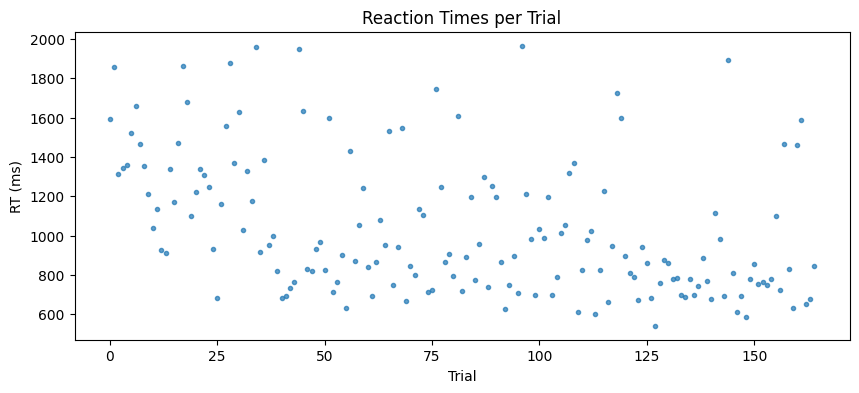


===== FINAL SUMMARY =====
✓ EEG shape correct
✓ RT length matches trials
✓ No missing RT values
✓ No invalid EEG values
✓ Ready for RIDE (assuming preprocessing was done correctly)


In [ ]:
# ---------------------------
# data overview
# ---------------------------
print("\n===== BASIC INFO =====")
print(f"Number of epochs: {len(epochs)}")
print(f"Metadata rows:    {len(epochs.metadata)}")

data = epochs.get_data()

print(f"\nEEG data shape:")
print(data.shape)
print("(n_trials, n_channels, n_timepoints)")

print(f"\nRT vector length:")
print(len(rt))

# ---------------------------
# shape checks 
# ---------------------------
print("\n===== SHAPE CHECKS =====")

assert data.shape[0] == len(rt), (
    f"Mismatch: EEG has {data.shape[0]} trials "
    f"but RT vector has {len(rt)} entries."
)

assert len(epochs) == len(epochs.metadata), (
    "Mismatch between epochs and metadata length."
)

print("✓ Trial count matches RT count")
print("✓ Metadata length matches epochs")

# ---------------------------
# metadata checks
# ---------------------------
print("\n===== METADATA CHECKS =====")

assert "RT" in epochs.metadata.columns, (
    "RT column not found in metadata."
)

n_missing = epochs.metadata["RT"].isna().sum()

print(f"Missing RT values: {n_missing}")

assert n_missing == 0, (
    f"There are {n_missing} missing RT values."
)

print("✓ No missing RT values")

# ---------------------------
# rt value checks
# ---------------------------
print("\n===== RT VALUE CHECKS =====")

print(f"RT min:  {np.min(rt):.2f} ms")
print(f"RT max:  {np.max(rt):.2f} ms")
print(f"RT mean: {np.mean(rt):.2f} ms")

assert np.all(np.isfinite(rt)), (
    "RT contains inf or NaN values."
)

assert np.all(rt > 0), (
    "RT contains zero or negative values."
)

# ---------------------------
# eeg data checks
# ---------------------------
print("\n===== EEG DATA CHECKS =====")

print(f"EEG dtype: {data.dtype}")

assert np.all(np.isfinite(data)), (
    "EEG data contains NaN or inf values."
)

print("✓ EEG contains only finite values")

# Check amplitude range
# MNE stores EEG in volts internally
data_uv = data * 1e6

print(f"Amplitude min: {np.min(data_uv):.2f} µV")
print(f"Amplitude max: {np.max(data_uv):.2f} µV")

large_artifacts = np.sum(np.max(np.abs(data_uv), axis=(1, 2)) > 150)

print(f"Trials with >150 µV artifact: {large_artifacts}")

if large_artifacts > 0:
    print("WARNING: Possible remaining artifacts.")

# ---------------------------
# TRIAL ALIGNMENT CHECK
# ---------------------------
print("\n===== TRIAL ALIGNMENT CHECK =====")

print("First 10 selected epochs:")
print(epochs.selection[:10])

print("\nFirst 5 metadata rows:")
print(epochs.metadata.head())

print("\nFirst 5 event codes:")
print(epochs.events[:5])

print("\n✓ Inspect manually whether metadata order matches epochs")

# ---------------------------
# CONDITION CHECK
# ---------------------------
print("\n===== CONDITION CHECK =====")

if "condition" in epochs.metadata.columns:
    print("Conditions found:")
    print(epochs.metadata["condition"].value_counts())

    print("\nIMPORTANT:")
    print("RIDE should be run separately per condition.")
else:
    print("No 'condition' column found in metadata.")

# ---------------------------
# RT DISTRIBUTION PLOT
# ---------------------------
print("\n===== PLOTTING RT DISTRIBUTION =====")

plt.figure(figsize=(10, 4))
plt.plot(rt, ".", alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("RT (ms)")
plt.title("Reaction Times per Trial")
plt.show()

# ---------------------------
# FINAL SUMMARY
# ---------------------------
print("\n===== FINAL SUMMARY =====")
print("✓ EEG shape correct")
print("✓ RT length matches trials")
print("✓ No missing RT values")
print("✓ No invalid EEG values")
print("✓ Ready for RIDE (assuming preprocessing was done correctly)")

In [23]:
sfreq = epochs.info['sfreq']
tmin, tmax = epochs.times[0], epochs.times[-1]

print("sfreq:", sfreq)
print("tmin:", tmin)
print("tmax:", tmax)
print("duration (sec):", tmax - tmin)
print("expected samples:", len(epochs.times))

sfreq: 256.0
tmin: -1.0
tmax: 2.19921875
duration (sec): 3.19921875
expected samples: 820


In [29]:
print("NaN count:", np.isnan(RT).sum())
print("Zero count:", np.sum(RT == 0))
print("Min/max:", np.nanmin(RT), np.nanmax(RT))
print("Length:", len(RT), "data trials:", data.shape[2])

NaN count: 0
Zero count: 0
Min/max: 138 503
Length: 165 data trials: 165
